[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/00-eda.ipynb)

In [1]:
%%capture
!pip install transformers datasets seqeval accelerate torch numpy
!pip install --upgrade transformers

In [2]:
import os
# Suppress all tqdm/HuggingFace progress bars before any library is imported
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"] = "1"

In [3]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
)

In [4]:
import os
os.environ["TQDM_DISABLE"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets import disable_progress_bars
disable_progress_bars()

from huggingface_hub.utils import disable_progress_bars as hub_disable_progress_bars
hub_disable_progress_bars()

In [5]:
# ==========================================
# 1. Load Dataset & Extract Labels
# ==========================================
dataset = load_dataset("Ben10x/MedMentions-MTI881-NER")

# The dataset stores tags as strings (e.g., 'B-T062', 'I-T062', 'O')
unique_tags = set()
for split in dataset.keys():
    for row in dataset[split]["ner_tags"]:
        unique_tags.update(row)

label_list = sorted(list(unique_tags))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

# ==========================================
# 2. Tokenization & Label Alignment
# ==========================================
model_id = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize_and_align_labels(examples):
    # Tokenize the pre-split words
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    for i, label_sequence in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens (like [CLS] and [SEP]) map to None. We set their label to -100 so they are ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # Only label the first token of a given word.
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label_sequence[word_idx]])
            # For subsequent tokens of the same word, also assign -100 (or you can assign the I- tag).
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

In [6]:
# ==========================================
# 3. Exploratory Data Analysis
# ==========================================
all_tags = [tag for sublist in dataset['train']['ner_tags'] for tag in sublist]
tag_counts = pd.Series(all_tags).value_counts()

# Separate 'O' from entities
o_count = tag_counts.get('O', 0)
entity_count = tag_counts.sum() - o_count

print(f"Number of unique tags: {len(tag_counts)}")
print(f"Total 'O' tags: {o_count}")
print(f"Total Entity tags: {entity_count}")
print(f"Percentage of 'O' tags: {o_count/tag_counts.sum()*100:.2f}%")

Number of unique tags: 105
Total 'O' tags: 492005
Total Entity tags: 154806
Percentage of 'O' tags: 76.07%


In [7]:
top_10_tags = tag_counts.drop('O').head(10)
print(top_10_tags)

B-T038    20103
B-T103    17845
I-T038    12515
B-T058    11835
I-T103    11233
B-T017    10129
I-T058     9688
B-T033     8009
I-T017     6070
B-T082     6069
Name: count, dtype: int64


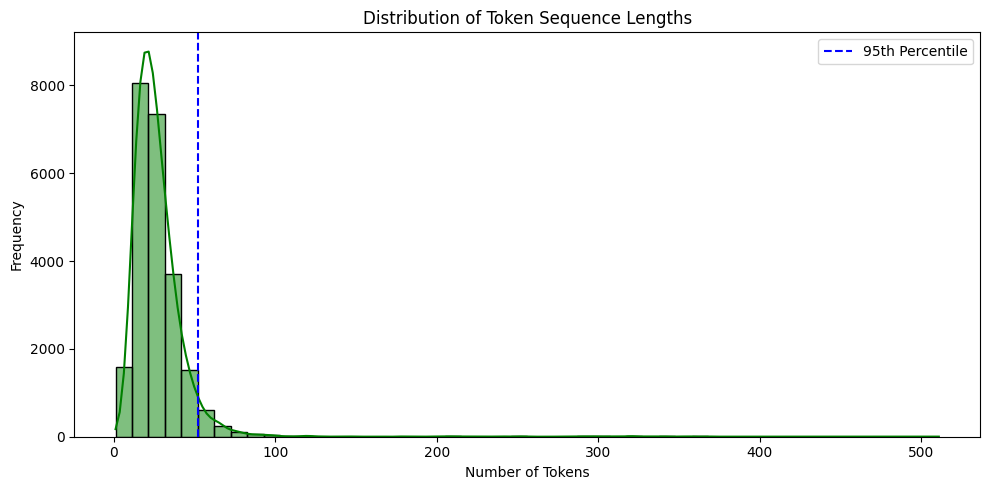

Saved: ner_length_distribution.png


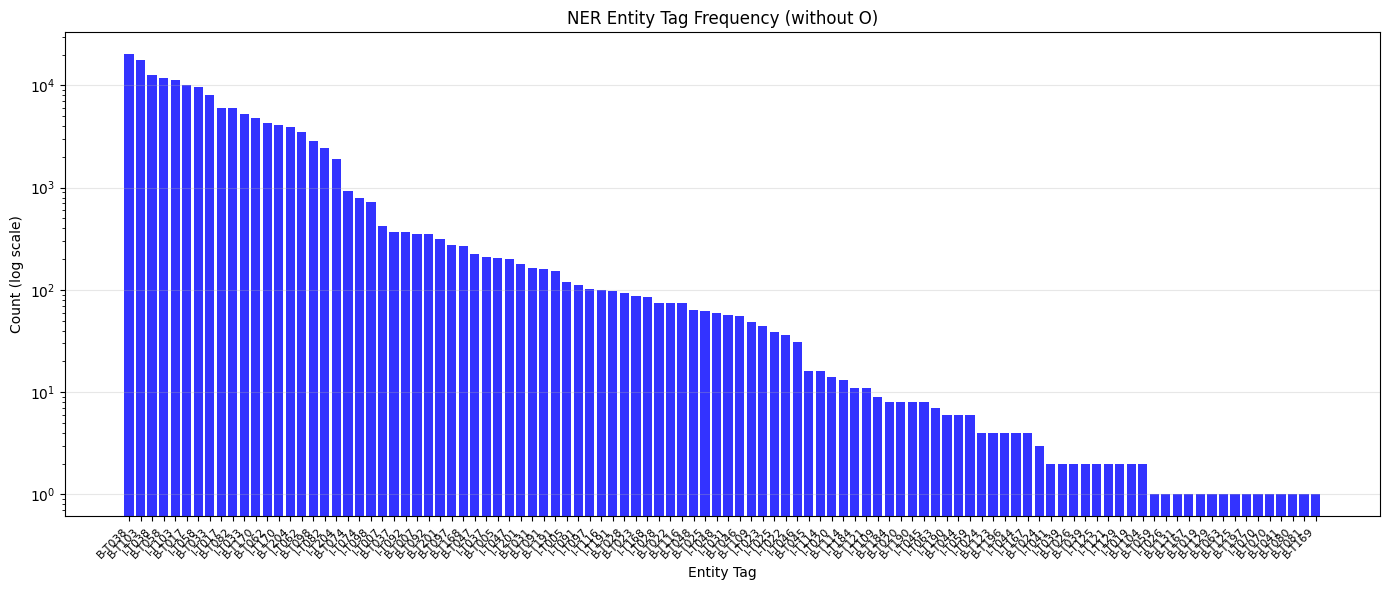

Saved: ner_tag_frequency.png


In [16]:
# Distribution of Token Sequence Lengths
seq_lengths = [len(tokens) for tokens in dataset['train']['tokens']]
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(seq_lengths, bins=50, kde=True, color='green', ax=ax)
ax.set_title('Distribution of Token Sequence Lengths')
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('Frequency')
ax.axvline(np.percentile(seq_lengths, 95), color='blue', linestyle='dashed', label='95th Percentile')
ax.legend()
plt.tight_layout()
plt.savefig('ner_length_distribution.png')
plt.show()
print("Saved: ner_length_distribution.png")

# Tag Frequency Bar Chart
tag_counts_without_o = tag_counts.drop('O', errors='ignore').sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(tag_counts_without_o)), tag_counts_without_o.values, color='blue', alpha=0.8)
ax.set_xticks(range(len(tag_counts_without_o)))
ax.set_xticklabels(tag_counts_without_o.index, rotation=45, ha='right', fontsize=8) # works now
ax.set_yscale('log')
ax.set_xlabel('Entity Tag')
ax.set_ylabel('Count (log scale)')
ax.set_title('NER Entity Tag Frequency (without O)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ner_tag_frequency.png')
plt.show()
print("Saved: ner_tag_frequency.png")

Top 5 highest weights (Rarest classes): [np.float64(5988.990740740741), np.float64(5988.990740740741), np.float64(5988.990740740741), np.float64(5988.990740740741), np.float64(5988.990740740741)]
Weight for 'O' class: 0.012172621702504528


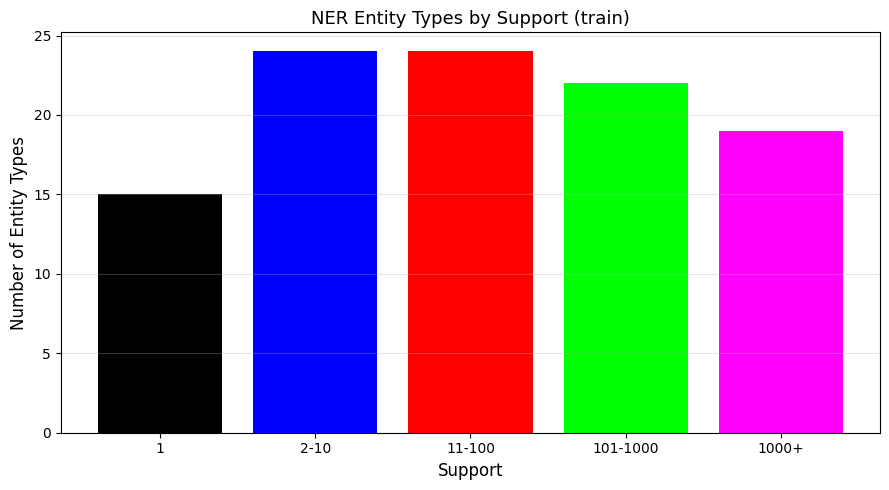

Saved: ner_entity_support_buckets.png
count
1           15
2-10        24
11-100      24
101-1000    22
1000+       19
Name: count, dtype: int64


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

all_tags_flat = [tag for sublist in dataset['train']['ner_tags'] for tag in sublist]
tag_counts = pd.Series(all_tags_flat).value_counts()

num_classes = len(label_list)
total_samples = tag_counts.sum()

class_weights_dict = {
    tag: total_samples / (num_classes * count)
    for tag, count in tag_counts.items()
}

class_weights = [class_weights_dict.get(id2label[i], 1.0) for i in range(num_classes)]

print("Top 5 highest weights (Rarest classes):", sorted(class_weights, reverse=True)[:5])
print("Weight for 'O' class:", class_weights_dict.get('O', 1.0))

# Entity Support (excluding 'O')
entity_counts = tag_counts.drop('O', errors='ignore')

def support_bucket(count):
    if count == 1:
        return '1'
    elif count <= 10:
        return '2-10'
    elif count <= 100:
        return '11-100'
    elif count <= 1000:
        return '101-1000'
    else:
        return '1000+'

buckets = entity_counts.apply(support_bucket)
bucket_order = ['1', '2-10', '11-100', '101-1000', '1000+']
bucket_counts = buckets.value_counts().reindex(bucket_order, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#000000', '#0000ff', '#ff0000', '#00ff00', '#ff00ff']
bars = ax.bar(bucket_order, bucket_counts.values, color=colors)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Number of Entity Types', fontsize=12)
ax.set_title('NER Entity Types by Support (train)', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ner_entity_support_buckets.png')
plt.show()
print("Saved: ner_entity_support_buckets.png")
print(bucket_counts)

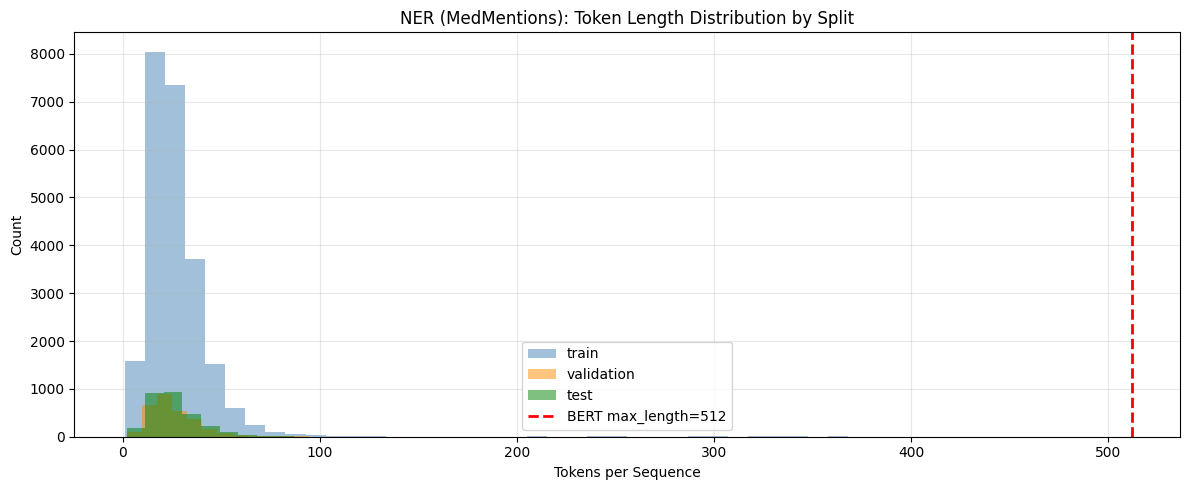

Saved: ner_length_by_split.png

Token length max:
train           511
validation      386
test            474


In [24]:
# NER: Token Length Distribution by Split
fig, ax = plt.subplots(figsize=(12, 5))
split_colors = {'train': 'steelblue', 'validation': 'darkorange', 'test': 'green'}
for split, color in split_colors.items():
    if split in dataset:
        lengths = [len(tokens) for tokens in dataset[split]['tokens']]
        ax.hist(lengths, bins=50, alpha=0.5, color=color, label=split)
ax.axvline(512, color='red', linestyle='--', linewidth=2, label='BERT max_length=512')
ax.set_xlabel('Tokens per Sequence')
ax.set_ylabel('Count')
ax.set_title('NER (MedMentions): Token Length Distribution by Split')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ner_length_by_split.png')
plt.show()
print("Saved: ner_length_by_split.png")

print("\nToken length max:")
for split in ['train', 'validation', 'test']:
    lengths = [len(tokens) for tokens in dataset[split]['tokens']]
    print(f"{split:<12} {max(lengths):>6}")

---
## MedQA-USMLE-4-Options Dataset EDA

In [12]:
from datasets import load_dataset
import pandas as pd
import numpy as np

qa_dataset = load_dataset("GBaker/MedQA-USMLE-4-options")
print("MedQA-USMLE-4-options splits:", {k: len(v) for k, v in qa_dataset.items()})
print("\nFeatures:", qa_dataset['train'].features)
print("\nSample record:")
sample = qa_dataset['train'][0]
for k, v in sample.items():
    v_str = str(v)[:120]
    print(f"  {k}: {v_str}")

MedQA-USMLE-4-options splits: {'train': 10178, 'test': 1273}

Features: {'question': Value('string'), 'answer': Value('string'), 'options': {'A': Value('string'), 'B': Value('string'), 'C': Value('string'), 'D': Value('string')}, 'meta_info': Value('string'), 'answer_idx': Value('string'), 'metamap_phrases': List(Value('string'))}

Sample record:
  question: A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago
  answer: Nitrofurantoin
  options: {'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Doxycycline', 'D': 'Nitrofurantoin'}
  meta_info: step2&3
  answer_idx: D
  metamap_phrases: ['23 year old pregnant woman', 'weeks presents', 'burning', 'urination', 'states', 'started 1 day', 'worsening', 'drinki


train
A: 2584 (25.4%)
B: 2654 (26.1%)
C: 2557 (25.1%)
D: 2383 (23.4%)
test
A: 353 (27.7%)
B: 309 (24.3%)
C: 346 (27.2%)
D: 265 (20.8%)


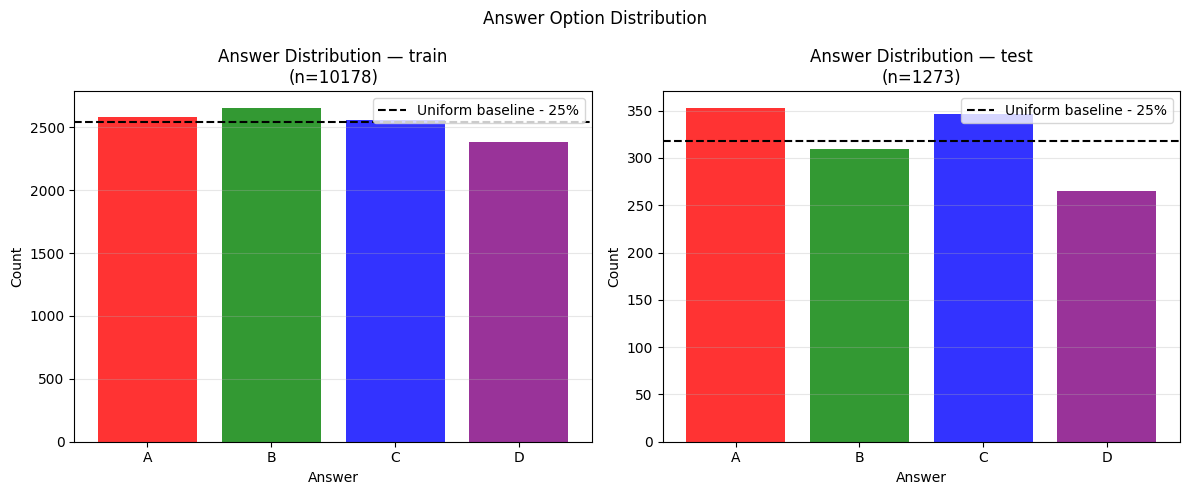

Saved: qa_answer_distribution.png


In [30]:
# Answer Option Distribution
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

option_names = ['A', 'B', 'C', 'D']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, split in zip(axes, ['train', 'test']):
    if split not in qa_dataset:
        ax.set_visible(False)
        continue
    # answer_idx is a string: 'A', 'B', 'C', or 'D'
    answer_letters = qa_dataset[split]['answer_idx']
    counts = pd.Series(answer_letters).value_counts().reindex(option_names, fill_value=0)
    ax.bar(option_names, counts.values, color=['red', 'green', 'blue', 'purple'], alpha=0.8)
    ax.axhline(y=len(answer_letters) / 4, color='black', linestyle='--', label='Uniform baseline - 25%')
    ax.set_xlabel('Answer')
    ax.set_ylabel('Count')
    ax.set_title(f'Answer Distribution — {split}\n(n={len(answer_letters)})')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    print(split)
    for opt, cnt in zip(option_names, counts.values):
        print(f"{opt}: {cnt} ({cnt / len(answer_letters) * 100:.1f}%)")

plt.suptitle('Answer Option Distribution')
plt.tight_layout()
plt.savefig('qa_answer_distribution.png')
plt.show()
print("Saved: qa_answer_distribution.png")

/tmp/ipykernel_3392/2177182471.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


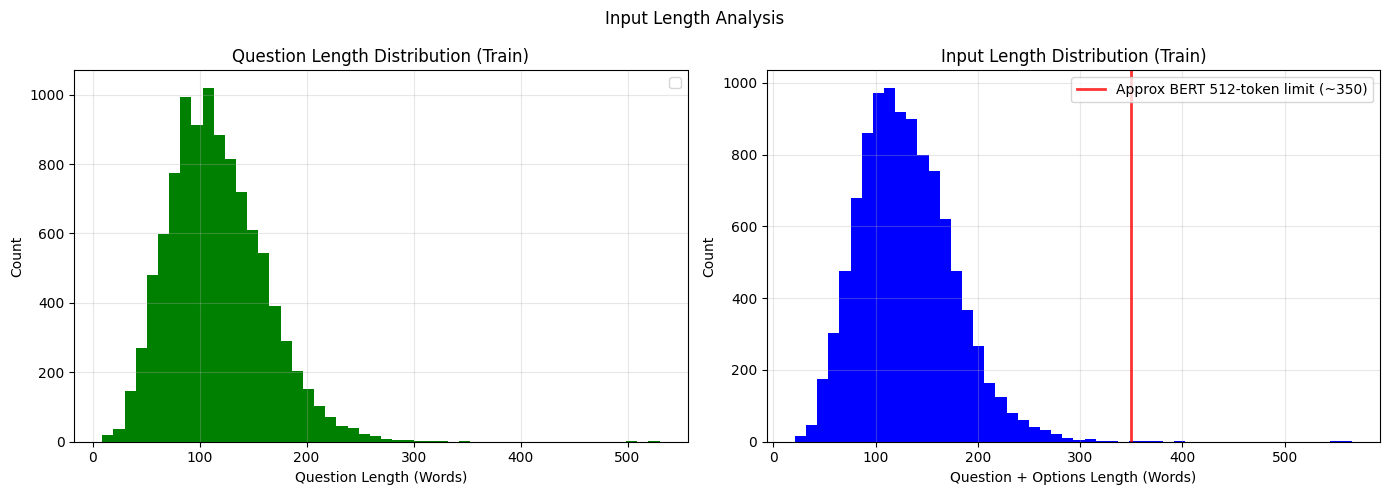

Saved: qa_length_distribution.png

Question length (words):
Mean: 116.2, Max: 530

Input length (question + options, words):
Mean: 130.2, Max: 566

Percentage of inputs exceeding BERT 512-token limit: 0.1%


In [41]:
import matplotlib.pyplot as plt
import numpy as np

train_q_lengths = [len(ex['question'].split()) for ex in qa_dataset['train']]
train_opt_lengths = []
for ex in qa_dataset['train']:
    opts = ex.get('options', {})
    if isinstance(opts, dict):
        combined = ex['question'] + ' ' + ' '.join(opts.values())
    else:
        combined = ex['question']
    train_opt_lengths.append(len(combined.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_q_lengths, bins=50, color='green')
axes[0].set_xlabel('Question Length (Words)')
axes[0].set_ylabel('Count')
axes[0].set_title('Question Length Distribution (Train)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(train_opt_lengths, bins=50, color='blue')
bert_512_approx = 350  # 512 tokens is about 350
axes[1].axvline(bert_512_approx, color='red', linestyle='-', linewidth=2, alpha=0.8,
                label=f'Approx BERT 512-token limit (~{bert_512_approx})')
axes[1].set_xlabel('Question + Options Length (Words)')
axes[1].set_ylabel('Count')
axes[1].set_title('Input Length Distribution (Train)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Input Length Analysis')
plt.tight_layout()
plt.savefig('qa_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qa_length_distribution.png")

# Summary stats
print("\nQuestion length (words):")

print(f"Mean: {np.mean(train_q_lengths):.1f}, Max: {max(train_q_lengths)}")
print(f"\nInput length (question + options, words):")
print(f"Mean: {np.mean(train_opt_lengths):.1f}, Max: {max(train_opt_lengths)}")

pct_truncated = sum(1 for l in train_opt_lengths if l > bert_512_approx) / len(train_opt_lengths) * 100
print(f"\nPercentage of inputs exceeding BERT 512-token limit: {pct_truncated:.1f}%")